Milestone 3: Neural Network Designs

In [1]:
import tensorflow as tf
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier
from pathlib import Path
from time import strftime
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=10,
                                                     restore_best_weights=True)

def get_run_logdir(root_logdir='my_logs'):
    return Path(root_logdir)/strftime("run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()

tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir,
                                                profile_batch=(100, 200))


def create_baseline(meta):
    X_shape_ = meta["X_shape_"]
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(300, activation="relu", input_shape=(X_shape_[1],)),
        tf.keras.layers.Dense(300, activation="relu"),
        tf.keras.layers.Dense(4, activation="softmax")
    ])
    model.compile(optimizer="adam", 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])
    return model


c:\Users\samue\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
clf = KerasClassifier(model=create_baseline, epochs=50, batch_size=32, verbose=1)

The results array will hold all of our results for each model to see which one performed the best for different metrics in the end

In [3]:
results = []

In [4]:
import numpy as np
from sklearn.svm import LinearSVC
data = np.load('octmnist.npz')
print("Keys in octmnist.npz: ", data.files)

for k in data.files:
    arr = data[k]
    print(f"{k:>12}: shape = {arr.shape}")

Keys in octmnist.npz:  ['train_images', 'val_images', 'test_images', 'train_labels', 'val_labels', 'test_labels']
train_images: shape = (97477, 28, 28)
  val_images: shape = (10832, 28, 28)
 test_images: shape = (1000, 28, 28)
train_labels: shape = (97477, 1)
  val_labels: shape = (10832, 1)
 test_labels: shape = (1000, 1)


In [5]:
train_images = data["train_images"]
train_labels = data["train_labels"].ravel()

val_images = data["val_images"]
val_labels = data["val_labels"].ravel()

test_images = data["test_images"]
test_labels = data["test_labels"].ravel()

In [6]:
from utils import flattener
from sklearn.preprocessing import MinMaxScaler

pipe_baseline = Pipeline([
    ("Flatten", flattener),
    ("Scale", MinMaxScaler()),
    ("model", clf)
])

In [7]:
from utils import train_eval_model
from utils import stratified_subset

x_tr, y_tr = stratified_subset(train_images, train_labels, 22000)
x_va, y_va = stratified_subset(val_images, val_labels, 2000)


In [8]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_tr)
sample_weights_valid = compute_sample_weight(class_weight="balanced", y=y_va)

In [9]:
results.append(train_eval_model(
    name="Baseline ANN",
    model=pipe_baseline,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    sample_weights=sample_weights,
    callbacks=[early_stopping_cb, tensorboard_cb]
))

c:\Users\samue\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4031 - loss: 1.3165
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4885 - loss: 1.2081
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5121 - loss: 1.1541
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5374 - loss: 1.1000
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5459 - loss: 1.0755
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5675 - loss: 1.0360
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5717 - loss: 1.0122
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5831 - loss: 0.9847
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5924 - loss: 0.9569
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5985 - loss: 0.9445
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6045 - loss: 0.9234
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

To absolutely no ones suprise even the completely untuned most baseline neural network possible sort of destroyed all other models.

In [10]:
from utils import median, avg_2x2_pool, flatten_data
from sklearn.preprocessing import FunctionTransformer

In [11]:


preprocess_nn = Pipeline([
    ("median", FunctionTransformer(median)),
    ("avg", FunctionTransformer(avg_2x2_pool)),
    ("flat", FunctionTransformer(flatten_data)),
    ("scale", MinMaxScaler()),
    ("model", clf)
])

results.append(train_eval_model(
    name="avg+median filtering results",
    model=preprocess_nn,
    x_tr=x_tr,
    x_va=x_va,
    y_tr=y_tr,
    y_va=y_va,
    sample_weights=sample_weights,
    callbacks=[early_stopping_cb, tensorboard_cb]
))

Epoch 1/50


c:\Users\samue\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4316 - loss: 1.3060
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5071 - loss: 1.2045
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5243 - loss: 1.1510
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5352 - loss: 1.1174
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5441 - loss: 1.0822
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5532 - loss: 1.0655
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5625 - loss: 1.0412
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5633 - loss: 1.0222
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5760 - loss: 1.0016
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5770 - loss: 0.9929
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5831 - loss: 0.9808
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

Performed Worse than on just the raw training data.

In [12]:
avg_nn = Pipeline([
    ("avg14", FunctionTransformer(avg_2x2_pool)),
    ("flat", FunctionTransformer(flatten_data)),
    ("scale", MinMaxScaler()),
    ("model", clf)
])


results.append(train_eval_model(
    name="avg filtering results",
    model=avg_nn,
    x_tr=x_tr,
    x_va=x_va,
    y_tr=y_tr,
    y_va=y_va,
    sample_weights=sample_weights,
    callbacks=[tensorboard_cb, early_stopping_cb]
))

Epoch 1/50


c:\Users\samue\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4170 - loss: 1.3052
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4988 - loss: 1.1916
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5324 - loss: 1.1346
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5550 - loss: 1.0843
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5625 - loss: 1.0466
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5769 - loss: 1.0123
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5883 - loss: 0.9860
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5928 - loss: 0.9618
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6036 - loss: 0.9371
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6095 - loss: 0.9224
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6091 - loss: 0.9069
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy

Once again overall a worse performance. Preprocessing appears to be a possible detriment for this.

All perfrom roughly similar with a slight edge to no preprocessing at this moment.

Now lets test results on a wide and deep network. The goal of a wide and deep network is to both hopefully learn simple patterns that can be learned just from the input data. As well as complex patterns that can be learned from the deep path too.

In [13]:
def create_wide_and_deep(meta):
    '''Creates the wide & deep network.
    deep network is designed to be same as pervious networks
    so we can guage if the width actually adds anything to the network.
    '''
    X_shape = meta["X_shape_"]
    print(X_shape)

    inputs= tf.keras.layers.Input(shape=(X_shape[1],))

    hidden_layer_1 = tf.keras.layers.Dense(300, activation='relu')(inputs)
    hidden_layer_2 = tf.keras.layers.Dense(300, activation='relu')(hidden_layer_1)

    concat_layer = tf.keras.layers.Concatenate()([inputs, hidden_layer_2])
    output_layer = tf.keras.layers.Dense(4, activation="softmax")(concat_layer)

    
    model = tf.keras.Model(inputs=inputs, outputs=output_layer)

    model.compile(optimizer="adam", 
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'])
    return model

clf_wide = KerasClassifier(model=create_wide_and_deep, epochs=50, batch_size=32, verbose=1)

pipe_baseline_wide = Pipeline([
    ("Flatten", FunctionTransformer(flatten_data)),
    ("Scale", MinMaxScaler()),
    ("model", clf_wide)
])

In [14]:
results.append(train_eval_model(
    name="Wide & Deep baseline model",
    model=pipe_baseline_wide,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    sample_weights=sample_weights,
    callbacks=[early_stopping_cb, tensorboard_cb]
))

(22000, 784)
Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3962 - loss: 1.3213
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4812 - loss: 1.2080
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5206 - loss: 1.1427
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5466 - loss: 1.0883
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5606 - loss: 1.0495
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5735 - loss: 1.0196
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5898 - loss: 0.9853
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6055 - loss: 0.9587
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6135 - loss: 0.9366
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6205 - loss: 0.9106
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6260 - loss: 0.8946
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━

Very consistent results but nothing incredible.

In [15]:
pipe_avg_wide = Pipeline([
    ("avg", FunctionTransformer(avg_2x2_pool)),
    ("Flatten", FunctionTransformer(flatten_data)),
    ("Scale", MinMaxScaler()),
    ("model", clf_wide)
])

results.append(train_eval_model(
    name="Wide & Deep Average",
    model=pipe_avg_wide,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    sample_weights=sample_weights,
    callbacks=[early_stopping_cb, tensorboard_cb]
))


(22000, 196)
Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4198 - loss: 1.2971
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5029 - loss: 1.1801
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5350 - loss: 1.1186
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5505 - loss: 1.0821
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5670 - loss: 1.0475
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5729 - loss: 1.0176
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5837 - loss: 0.9903
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6015 - loss: 0.9607
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6052 - loss: 0.9473
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6101 - loss: 0.9213
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6169 - loss: 0.9063
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━

Best Accuracy So Far, but lower precision

In [16]:
pipe_med_avg_wide = Pipeline([
    ("med", FunctionTransformer(median)),
    ("avg", FunctionTransformer(avg_2x2_pool)),
    ("Flatten", FunctionTransformer(flatten_data)),
    ("Scale", MinMaxScaler()),
    ("model", clf_wide)
])

results.append(train_eval_model(
    name="Wide & Deep Median + Avg model",
    model=pipe_med_avg_wide,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    sample_weights=sample_weights,
    callbacks=[early_stopping_cb, tensorboard_cb]
))

(22000, 196)
Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4304 - loss: 1.3104
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4974 - loss: 1.2013
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5203 - loss: 1.1539
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5334 - loss: 1.1181
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5469 - loss: 1.0847
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5550 - loss: 1.0610
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5682 - loss: 1.0328
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5682 - loss: 1.0235
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5766 - loss: 1.0085
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5867 - loss: 0.9881
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5939 - loss: 0.9649
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━

In [17]:
def create_wide_and_deep_subsample(meta, wide_frac=0.5, deep_frac=0.5, seed=42):
    X_shape_ = meta["X_shape_"]
    n_features = X_shape_[1]

    rng = np.random.RandomState(seed)
    wide_idx = rng.choice(n_features, size=int(n_features * wide_frac), replace=False)
    deep_idx = rng.choice(n_features, size=int(n_features * deep_frac), replace=False)

    inputs = tf.keras.layers.Input(shape=(n_features,))

    wide_input = tf.keras.layers.Lambda(lambda x: tf.gather(x, wide_idx, axis=1))(inputs)
    deep_input = tf.keras.layers.Lambda(lambda x: tf.gather(x, deep_idx, axis=1))(inputs)

    # Deep path
    deep = tf.keras.layers.Dense(300, activation="relu")(deep_input)
    deep = tf.keras.layers.Dense(300, activation="relu")(deep)

    # Concatenate
    concat = tf.keras.layers.Concatenate()([wide_input, deep])

    output = tf.keras.layers.Dense(4, activation="softmax")(concat)

    model = tf.keras.Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"]
    )
    return model

clf_wide_subsample = KerasClassifier(model=create_wide_and_deep_subsample, epochs=50, batch_size=32, verbose=1)

pipe_wide_subsample_base = Pipeline([
    ("flat", flattener),
    ("scale", MinMaxScaler()),
    ("model", clf_wide_subsample)
])

results.append(train_eval_model(
    name="Wide & Deep with feature subsampling",
    model=pipe_wide_subsample_base,
    x_tr=x_tr,
    x_va=x_va,
    y_tr=y_tr,
    y_va=y_va,
    sample_weights=sample_weights,
    callbacks=[early_stopping_cb, tensorboard_cb]
))


Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3925 - loss: 1.3209
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4680 - loss: 1.2159
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5079 - loss: 1.1575
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5418 - loss: 1.0993
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5638 - loss: 1.0578
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5758 - loss: 1.0148
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6050 - loss: 0.9834
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6099 - loss: 0.9478
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6230 - loss: 0.9266
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6300 - loss: 0.9010
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6398 - loss: 0.8778
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/ste

In [18]:
def prep_for_cnn(X):
    X = X.astype("float32") / 255.0
    X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
    return X

In [19]:
#we first need to make sure the data is ready for a cnn (see utils helper)
x_tr_cnn = prep_for_cnn(x_tr) #train
x_va_cnn = prep_for_cnn(x_va) #validation

In [20]:
from tensorflow import keras

def make_cnn():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28, 1)),
        keras.layers.Conv2D(64, kernel_size=3, activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2), #2x2
        keras.layers.Conv2D(32, kernel_size=3, activation="relu"),
        keras.layers.MaxPooling2D(pool_size=2),
        keras.layers.Flatten(),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [64]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_eval_cnn(name, model, x_tr, y_tr, x_va, y_va, sample_weights, callbacks=None):
    t1 = time.time()

    history = model.fit(
        x_tr, y_tr,
        validation_data=(x_va, y_va),
        epochs=50,
        batch_size=32,
        sample_weight=sample_weights,
        callbacks=callbacks,
        verbose=1
    )

    t2 = time.time()

    probs = model.predict(x_va)
    pred = probs.argmax(axis=1)

    acc = accuracy_score(y_va, pred)
    prec = precision_score(y_va, pred, average="weighted")
    rec = recall_score(y_va, pred, average="weighted")
    f1 = f1_score(y_va, pred, average="weighted")
    train_time = t2-t1

    print(f"Model: {name}")
    print(f"Training Time: {t2-t1}")
    print(f"acc: {acc}")
    print(f"prec: {prec}")
    print(f"recall: {rec}")

    return history, {
        "name": name,
        "time": round(train_time, 3),
        "acc": round(acc, 4),
        "prec": round(prec, 4),
        "recall": round(rec, 4),
        "f1": f1
    }

In [65]:
cnn_model = make_cnn()
cnn_history, cnn_result = train_eval_cnn(
    name="Simple CNN",
    model=cnn_model, #using the model we created
    x_tr=x_tr_cnn, 
    y_tr=y_tr,
    x_va=x_va_cnn, 
    y_va=y_va,
    sample_weights=sample_weights,
    callbacks=[early_stopping_cb]
)

results.append(cnn_result)

Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5729 - loss: 1.1531 - val_accuracy: 0.6545 - val_loss: 0.8564
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6725 - loss: 0.8972 - val_accuracy: 0.6570 - val_loss: 0.8500
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6980 - loss: 0.8098 - val_accuracy: 0.7265 - val_loss: 0.7373
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7110 - loss: 0.7569 - val_accuracy: 0.6610 - val_loss: 0.8091
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7197 - loss: 0.7283 - val_accuracy: 0.7555 - val_loss: 0.6367
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7310 - loss: 0.6972 - val_accuracy: 0.7680 - val_loss: 0.6112
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7389 - loss: 0.6721 - val_accuracy: 0.5615 - val_loss: 0.9077
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7405 - loss: 0.6545 - val_accuracy: 0.

In [66]:
def prep_median_for_cnn(X):
    X_med = median(X)
    X_med = X_med.astype("float32") / 255.0
    X_med = X_med.reshape(X_med.shape[0], X_med.shape[1], X_med.shape[2], 1)
    return X_med

In [67]:
x_tr_cnn_med = prep_median_for_cnn(x_tr)
x_va_cnn_med = prep_median_for_cnn(x_va)

In [83]:
cnn_med_model = make_cnn()
cnn_med_history, cnn_med_result = train_eval_cnn(
    "Median CNN",
    cnn_med_model,
    x_tr_cnn_med, y_tr,
    x_va_cnn_med, y_va,
    sample_weights=sample_weights
)

results.append(cnn_med_result)

Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5282 - loss: 1.2164 - val_accuracy: 0.6620 - val_loss: 0.9174
Epoch 2/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6278 - loss: 0.9817 - val_accuracy: 0.6990 - val_loss: 0.8255
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6520 - loss: 0.8997 - val_accuracy: 0.6820 - val_loss: 0.8470
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6705 - loss: 0.8554 - val_accuracy: 0.6125 - val_loss: 0.8659
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6764 - loss: 0.8202 - val_accuracy: 0.6620 - val_loss: 0.7945
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6830 - loss: 0.7889 - val_accuracy: 0.6735 - val_loss: 0.7852
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6952 - loss: 0.7624 - val_accuracy: 0.5675 - val_loss: 0.9277
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7036 - loss: 0.7420 - val_accuracy: 0.

The wide and deep model performed slightly better than the baseline model. Interestingly there seems to be a percision recall trade off between averaging for this case. When averaging to reduce dimensionality the precision dropped but the recall increased. I would interpret this as the model sort of being more 'certain' or 'aggressive' in it's guessing leading to more total positive cases captured on average per class but also less overall accuracy on those guesses. Ultimately we should take both these into consideration especially when acknowledging that our models are tuned for Accuracy (Marco Recall).

Let us now look towards tuning an existing model and observe the results there. First we will explore general ideas in model architecture. Number of layers, number of neurons, learning rate, and basic optimimizer choices. This can help us get more insight into what kind of model architectures are doing well for this problem.

In [26]:
import keras_tuner as kt

def build_tuned_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")

    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    avg = hp.Choice("avg", values=[True, False])
    pool = hp.Int("pool_size", min_value=2, max_value=4)
    activation = hp.Choice("activation", values=["relu", "leaky_relu", "elu", "selu"])
    batch_norm = hp.Choice("batch_norm", values=[True, False])
    decay_rate = hp.Float("decay_rate", min_value=0.9, max_value=0.99, step=0.01)

    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=learning_rate,
                decay_steps=100,
                decay_rate=decay_rate,
            )
        )
    else:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=learning_rate,
                decay_steps=100,
                decay_rate=decay_rate,
            )
        )

    model = tf.keras.Sequential()

    if avg:
        model.add(tf.keras.layers.Reshape((28, 28, 1))) #Added because 4d data is expected for average pooling
        model.add(tf.keras.layers.AveragePooling2D(pool_size=(pool, pool)))

    model.add(tf.keras.layers.Rescaling(scale=1.0 / 255)) #Our MinMaxScaler in tensorflow format

    model.add(tf.keras.layers.Flatten())

    dropout_rate = hp.Float("dropout", min_value=0.0, max_value=0.5, step=0.1)

    for i in range(n_hidden):
        n_neurons = hp.Int(f"n_neurons{i}", min_value=16, max_value=256)
        model.add(tf.keras.layers.Dense(n_neurons, activation=activation))
        if batch_norm:
            model.add(tf.keras.layers.BatchNormalization())
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))
    model.add(tf.keras.layers.Dense(4, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

This is a pretty deep tuning search. so lets break it down.
1. This allows us first and formost give a general idea of what model architecture is preferred (deep path vs shallow, wide layers vs small layers)
2. Control our preprocessing step through the averaging choice.
3. Have a preliminary search over activation functions & optimizers
4. Introduce batch normalization & dropout rate if it is beneficial.

In [82]:
tuner = kt.RandomSearch(
    build_tuned_model,
    objective="val_accuracy",
    max_trials=50,
    directory="tuning_results",
    project_name="my_rnd_search",
)
'''
tuner.search(
    x_tr, y_tr,
    epochs=50,
    validation_data=(x_va, y_va),
    callbacks=[
        early_stopping_cb,
        tensorboard_cb
    ]
)
'''

def train_eval_no_wrapper(name, model, x_tr, y_tr, x_va, y_va, sample_weights, callbacks=[]):
    '''trains and evaluates the model'''
    t1 = time.time()
    model.fit(x_tr, y_tr, epochs=50, sample_weight=sample_weights, callbacks=callbacks)
    t2 = time.time()

    probs = model.predict(x_va)
    pred = probs.argmax(axis=1)

    acc    = accuracy_score(y_va, pred)
    prec   = precision_score(y_va, pred, average="weighted", zero_division=1)
    recall = recall_score(y_va, pred, average="weighted", zero_division=1)
    f1 = f1_score(y_va, pred, average="weighted", zero_division=1)

    print(f"Model: {name}")
    print(f"Training Time: {t2-t1:.3f}")
    print(f'acc: {acc:.4f}')
    print(f'prec:{prec:.4f}')
    print(f'recall:{recall:.4f}\n')

    return {"name": name, "time":t2-t1, "acc": acc, "prec":prec, "recall":recall, "f1": f1}

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model =tuner.hypermodel.build(best_hp)

results.append(train_eval_no_wrapper(
    name="Best Random Search",
    model=best_model,
    x_tr=x_tr,
    y_tr=y_tr,
    x_va=x_va,
    y_va=y_va,
    sample_weights=sample_weights,
    callbacks=early_stopping_cb
))

Reloading Tuner from tuning_results\my_rnd_search\tuner0.json
Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3627 - loss: 1.3981
Epoch 2/50
 37/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3783 - loss: 1.1962

c:\Users\samue\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4420 - loss: 1.2384
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4876 - loss: 1.1682
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5215 - loss: 1.1108
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5432 - loss: 1.0599
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5567 - loss: 1.0262
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5769 - loss: 0.9916
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5974 - loss: 0.9477
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5981 - loss: 0.9160
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6101 - loss: 0.8855
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6218 - loss: 0.8657
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6294 - loss: 0.8454
Epoch 13/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accurac

Interesting! an extremely deep network is preferred. With a range of 100-200 per network. Batch normalization is preferred. Averaging is not required. We are using Batch Normalization and have a decay rate of around .97

Some notes after looking in Tensorboard:
1. Activation Function has no clear winner even after looking at ~10 best models.
2. Similarly averaging doesn't seem to have that big of a difference. The absolute best performed well without it though.
3. Batch norm performed best on the best models, but also had a fairly large split.
4. Higher decay rate seems (mostly preferred)
5. Dropout of zero is MOST LIKELY BEST. biggest indicator so far.

Everything else had a fairly large spread. Lets assume a lower dropout rate and try a different tuning method and see if we can gain more info. Since Selu Won last time we are going to try introducion a norm layer to see if that combo with selu and batch norm can get us somewhere.

this inital search was quite flawed. We respectfully ask you don't consider it when grading, it is being included so you can still observe thought process and progression.

Reasons it was flawed:
1. Selu was used without normalization layer (stupid mistake)
2. learning rate wasn't kept constant (MASSIVE MISTAKE). because of this a potentially great model could have performed poorly due to having too high a learning rate or too low a learning rate. Keeping it consistent is ideal, but even better is putting measures in place to make sure learning rate is less of a factor.
3. The inclusion of preprocessing screening may muddle the search for an ideal model. Averaging twice could drop performance of an otherwise good model by a lot. this muddles our search for truly well architectured model.

In [28]:
len(x_tr) // 32

687

In [29]:
from utils import flatten_data

def build_tuned_wide_and_deep(hp, meta, mean, variance, seed=42):
    X_shape = meta["X_shape_"]
    n_features = X_shape[1]

    activation = hp.Choice("activation", values=["relu", "leaky_relu", "elu", "selu"])
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    #learning_rate = hp.Choice("learning_rate", values=[3e-4, 1e-3])
    #optimizer = hp.Choice("optimizer", values=["sgd", "adam"]) #Just adam for now
    batch_norm = hp.Boolean("batch_norm")
    #decay_rate = hp.Float("decay_rate", min_value=0.9, max_value=0.99, step=0.01)
    wide_and_deep = hp.Boolean("wide_and_deep")
    if wide_and_deep:
        wide_frac = hp.Float("wide_frac", min_value=.7, max_value=1)
        deep_frac = hp.Float("deep_frac", min_value=.7, max_value=1)
        rng = np.random.RandomState(seed)
        wide_idx = rng.choice(n_features, size=int(n_features * wide_frac), replace=False)
        deep_idx = rng.choice(n_features, size=int(n_features * deep_frac), replace=False)
    else:
        deep_idx = np.arange(0, n_features)
    '''
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=learning_rate,
                decay_steps=100,
                decay_rate=decay_rate,
            )
        )
    '''
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=3e-3,
        decay_steps=687 * 50,
        warmup_target=3e-3,
        warmup_steps=687 * 2,  # 2 epochs of warmup
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    inputs = tf.keras.layers.Input(shape=(n_features,))

    if activation == "selu":
        norm_layer = tf.keras.layers.Normalization(mean=mean, variance=variance)
        preprocessing = norm_layer(inputs)
    else:
        preprocessing = tf.keras.layers.Rescaling(1./255)(inputs)
    
    if wide_and_deep:
        wide_input = tf.keras.layers.Lambda(lambda x: tf.gather(x, wide_idx, axis=1))(preprocessing)

    deep_input = tf.keras.layers.Lambda(lambda x: tf.gather(x, deep_idx, axis=1))(preprocessing)

    last_layer = deep_input
    for i in range(n_hidden):
        n_neurons = hp.Int(f"n_neurons{i}", min_value=16, max_value=256)
        last_layer = tf.keras.layers.Dense(n_neurons, activation=activation)(last_layer)
        if batch_norm:
            last_layer = tf.keras.layers.BatchNormalization()(last_layer)
    
    if wide_and_deep:
        last_layer = tf.keras.layers.Concatenate()([last_layer, wide_input])

    outputs = tf.keras.layers.Dense(4, activation="softmax")(last_layer)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

class MyTuningModel(kt.HyperModel):
    def __init__(self, meta, x_tr):
        super().__init__()
        self.meta = meta
        norm_layer = tf.keras.layers.Normalization()
        norm_layer.adapt(x_tr)
        self.mean_, self.var_ = norm_layer.get_weights()[0], norm_layer.get_weights()[1] #getting our mean and var incase we use selu


    def fit(self, hp, model, X, y, **kwargs):
        '''
        if hp.Boolean("median"):
            X = median(X)
        if hp.Boolean("avg"):
            X = avg_2x2_pool(X)

        '''

        X = flatten_data(X)

        return model.fit(X, y, **kwargs)
    
    def build(self, hp):
        return build_tuned_wide_and_deep(hp, self.meta, mean=self.mean_, variance=self.var_)
        




To briefly explain my rationale. My goal here is to build an overal architecture that works well. Things like number of layers, whether or not to use wide and deep, number of nodes per layer, activation function, things that have a wide sweeping impact on the overall model is what we are titrating for right now. Because of this some ideas that I was originally going to include have been commented out as they may muddy my original objective. I experienced a little bit of "Search Creep" when making this where I just kept adding more and more to the search and felt like my net was cast too wide, so we have cut back to what we need. Maybe most critical difference from the first search: The learning rate is being constrained. This parameter controls too much of performance so it was opted to be constrained. Sample weights are also being introduced as we want to make sure the model generalizes well to all classes, a decision that in hindsight should've been made long ago

In [30]:
run_logdir = get_run_logdir('my_logs/architecture_search')

tensorboard_cb =  tf.keras.callbacks.TensorBoard(run_logdir)
#profile batching is removed (the callback was taken from the textbook)
#profile batching just collects data on general performance metrics
#such as how long something takes on the CPU
#or which layer is the slowests
#since our hyperparameters are changing constantly this info isn't very useful.



It's time to go into more detail on Tuner Selection. Looking at documentation there is really 4 choices:
1. RandomSearch
2. GridSearch
3. BayesianOptimization
4. Hyperband

GridSearch is by far the easiest to rule out we are searching over so many parameters it would just be impossible to scan over all of them. Especially when we are dealing with continuous variables.
Random Search vs Hyperband is a tougher choice. Hyperband could essentially be viewed as a 'smarter' Random Search. However this search will be done for a WHILE. and because of this we are able to be far more forgiving on what Hyperband tends to explore while still maintaining the cost cutting benefits of it. So in actuality this should lead to just more raw models being explored.
Finally we have Bayesian optimization: The problem here is in structure versus execution. Bayesian optimization assumes a function:
 f(hyperparemeters) -> Loss/Val_accuracy/accuracy that we can model. Essentially something like given these datapoints probability that our function looks like this is. and then probes new points smartly based around where in the feature space we know is good and where is unknown. The problem with this is the inital assumption. Bayesian optimization assumes that if you have mostly similar hyperparameters you will get mostly a similar results. And this is simply not the case with our design, because we have Booleans. If we used a boolean for wide and deep for example and it was true and had a deep layer of 2, we might wrongly explore that the feature space with deep layers of 2 for action space of two and generalize this architectures where it doesn't belong like a non wide and deep model. The reality is our model is certianly not continuous in nature. something as simple as chaning wide & deep can mean massive changes for what is optimal for the other hyperparameters, the feature space is likely jagged and rough. This is an exaggeration of the problem, in practice BayesianOptimization would probably still work well, but perhaps not the best. 

In [31]:
x_tr_flat = flatten_data(x_tr)
x_va_flat = flatten_data(x_va) 
#flattening so preprocessing runs smoothly

meta = {"X_shape_": (x_tr_flat.shape[0], x_tr_flat.shape[1])} #Necessary to give the model and idea of input shape
#already preflatted so logic stayes the same

print("x_tr_flat shape:", x_tr_flat.shape)
print("x_va_flat shape:", x_va_flat.shape)
print("meta:", meta)
print("sample_weights shape:", sample_weights.shape)
print("sample_weights_valid shape:", sample_weights_valid.shape)

x_tr_flat shape: (22000, 784)
x_va_flat shape: (2000, 784)
meta: {'X_shape_': (22000, 784)}
sample_weights shape: (22000,)
sample_weights_valid shape: (2000,)


The idea behind this is that: A poor architecture model will still perform a good architecture model with a learning rate that causes diveragence or too low training. Our solution to this is twofold: One we will use a learning_rate schedule. A learning rate schedule modifies the learning rate as training goes on to solve this very problem. We will use Cosine Decay with a warm up. We will start out with a higher learning rate so slower models can catch up quickly then quickly peel back as we aproach optimal solutions. Secondly we will use the above callback. if training is not improving from the aggressive start it will begin lowering the learning rate in hopes that it will peel back in time.

I plan on letting this run overnight so we'll see the results in the morning. I am not too concerned with training time because of this.

In [32]:
tuner = kt.Hyperband(
    hypermodel=MyTuningModel(meta=meta, x_tr=x_tr_flat),
    objective="val_accuracy",
    max_epochs=75,
    factor=2,
    hyperband_iterations=3,
    directory="./hyperband_dir",
    project_name="Architecture_tuning",
    overwrite=False,
    seed=42
    )

'''
tuner.search(
    x_tr_flat, 
    y_tr,
    validation_data=(x_va_flat, y_va, sample_weights_valid),
    sample_weight=sample_weights,
    batch_size=32,
    callbacks=[early_stopping_cb, tensorboard_cb],
    verbose=1
)
'''

Reloading Tuner from ./hyperband_dir\Architecture_tuning\tuner0.json


'\ntuner.search(\n    x_tr_flat, \n    y_tr,\n    validation_data=(x_va_flat, y_va, sample_weights_valid),\n    sample_weight=sample_weights,\n    batch_size=32,\n    callbacks=[early_stopping_cb, tensorboard_cb],\n    verbose=1\n)\n'

1076 Different Neural Network Architectures built and tested lets see the results. I am running into a very annoying problem. I now have too much data for my laptop to open with Tensorboard. My laptop is literally crashing as I try to open it. And I can't upload it to the github as that is too intensive for my laptop as well.

In [33]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model_hyper = tuner.hypermodel.build(best_hp)

best_model_hyper.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 184)            │       144,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 184)            │           736 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 206)            │        38,110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 206)            │           824 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 192)            │        39,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 120)            │        23,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 120)            │           480 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 138)            │        16,698 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 138)            │           552 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 4)              │           556 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,068 (1.01 MB)

 Trainable params: 264,388 (1.01 MB)

 Non-trainable params: 1,680 (6.56 KB)

In [34]:
results.append(train_eval_no_wrapper(
                 model=best_model_hyper, 
                 name="Best Hyperband Result", 
                 x_tr=x_tr_flat, 
                 y_tr=y_tr,
                 x_va=x_va_flat,
                 y_va=y_va,
                 sample_weights=sample_weights,
                 callbacks=[early_stopping_cb]))

Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4300 - loss: 1.2905
Epoch 2/50
 41/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5151 - loss: 1.1424

c:\Users\samue\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5052 - loss: 1.1554
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5413 - loss: 1.0860
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5732 - loss: 1.0186
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5901 - loss: 0.9735
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6099 - loss: 0.9234
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6196 - loss: 0.8983
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6362 - loss: 0.8761
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6428 - loss: 0.8390
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6515 - loss: 0.8196
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6566 - loss: 0.7954
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6661 - loss: 0.7724
Epoch 13/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accurac

Had to reload as my laptop crashed trying to access tensorboard.

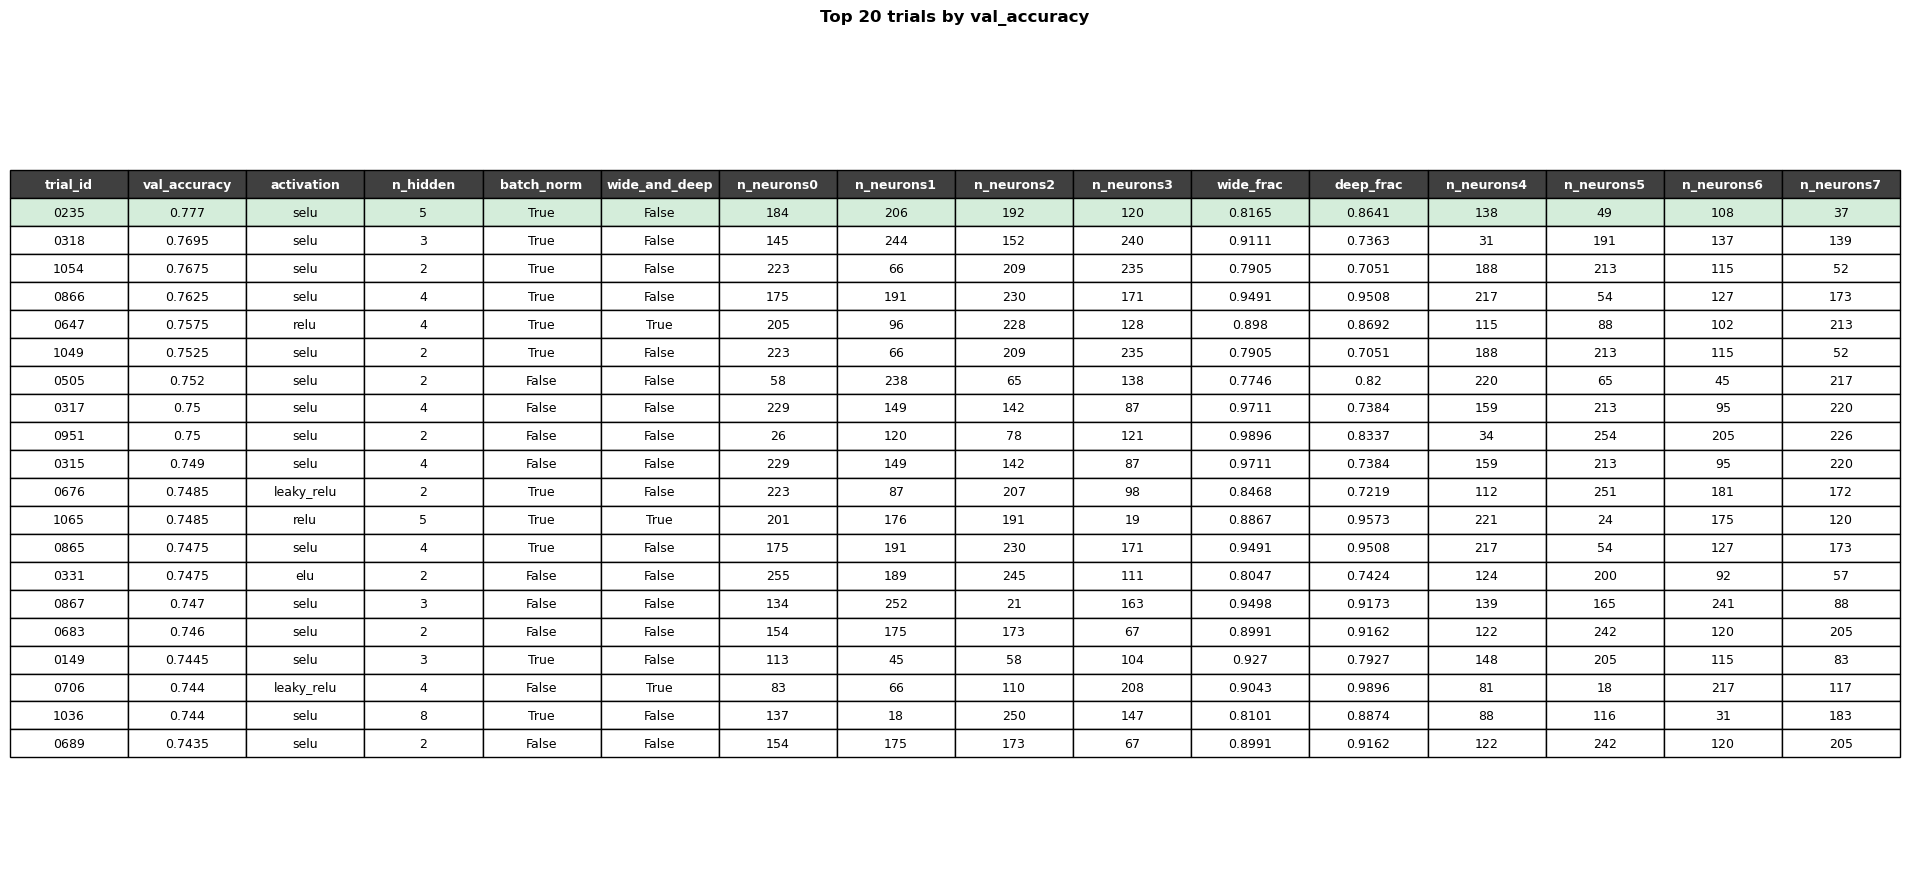

In [35]:
import matplotlib.pyplot as plt
import pandas as pd


trials = tuner.oracle.get_best_trials(num_trials=100)
rows = []
for trial in trials:
    row = {"trial_id": trial.trial_id, "val_accuracy": trial.score}
    row.update(trial.hyperparameters.values)
    rows.append(row)
df = pd.DataFrame(rows).sort_values("val_accuracy", ascending=False).reset_index(drop=True)


# Figure 1: top 20 trials as a table
top20 = df.head(20).copy()

# Drop columns that aren't useful in the display (keep if you want them)
cols_to_show = [c for c in top20.columns if c not in {"tuner/trial_id", "tuner/epochs", "tuner/initial_epoch", "tuner/bracket", "tuner/round"}]
top20_display = top20[cols_to_show]

# Round floats for readability
for col in top20_display.select_dtypes(include="float").columns:
    top20_display[col] = top20_display[col].round(4)

fig, ax = plt.subplots(figsize=(max(12, len(cols_to_show) * 1.2), len(top20_display) * 0.4 + 1))
ax.axis("off")
table = ax.table(
    cellText=top20_display.values,
    colLabels=top20_display.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

# Bold the header row
for j in range(len(top20_display.columns)):
    cell = table[0, j]
    cell.set_text_props(weight="bold")
    cell.set_facecolor("#404040")
    cell.set_text_props(color="white")

# Highlight the best row
for j in range(len(top20_display.columns)):
    table[1, j].set_facecolor("#d4edda")

ax.set_title("Top 20 trials by val_accuracy", pad=20, fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig("top20_trials.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Some notes here: Of the activations Selu is definitely the majority.
n_hidden varies quite a lot. seems to mostly be constrainted in the 2-4 range though. (shallower networks).
Batch norm has quite the mix. This makes sense as Selu is a replacement for BatchNorm.
Wide & Deep is majority False.
Neuron count should maybe have been held constant across layers. Hard to interperet, however there is often a slight dip in neuron count in the models last layer.

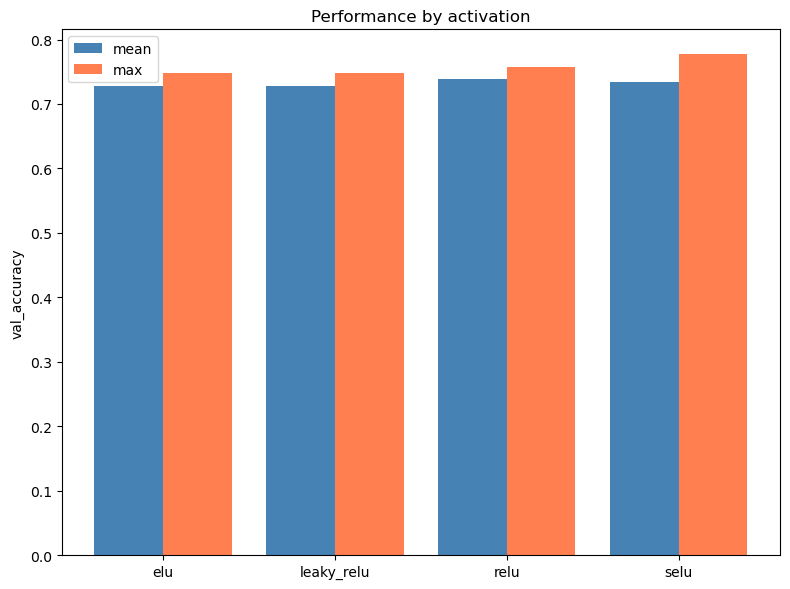

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))
activation_stats = df.groupby("activation")["val_accuracy"].agg(["mean", "max"])
x = range(len(activation_stats))
ax.bar([i - 0.2 for i in x], activation_stats["mean"], width=0.4, label="mean", color="steelblue")
ax.bar([i + 0.2 for i in x], activation_stats["max"], width=0.4, label="max", color="coral")
ax.set_xticks(x)
ax.set_xticklabels(activation_stats.index)
ax.set_ylabel("val_accuracy")
ax.set_title("Performance by activation")
ax.legend()
plt.tight_layout()
plt.savefig("activation_performance.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

While their averages are roungly the same selu has a much higher peak.

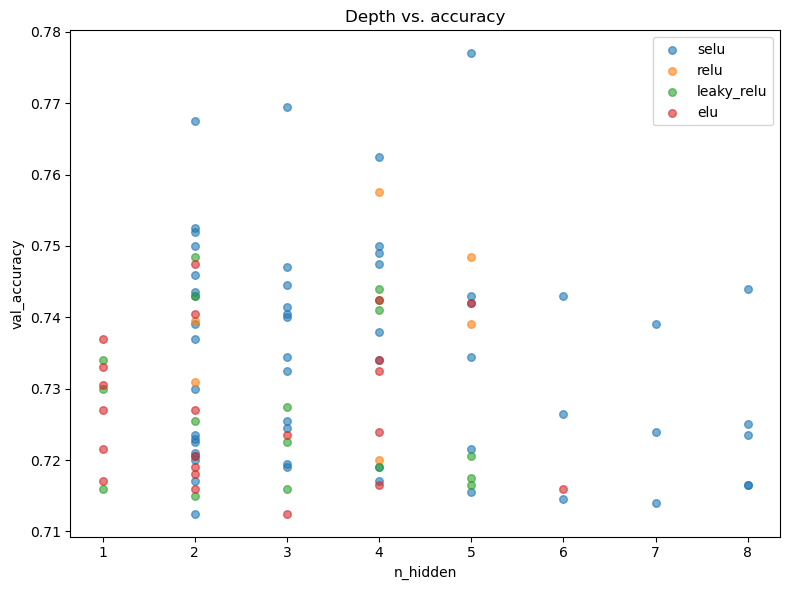

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
for activation in df["activation"].unique():
    subset = df[df["activation"] == activation]
    ax.scatter(subset["n_hidden"], subset["val_accuracy"],
               label=activation, alpha=0.6, s=30)
ax.set_xlabel("n_hidden")
ax.set_ylabel("val_accuracy")
ax.set_title("Depth vs. accuracy")
ax.legend()
plt.tight_layout()
plt.savefig("depth_vs_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Generally Selu is performing the best once again. specifically on deeper models. too. the best accuracy for each layer except 1 is Selu.

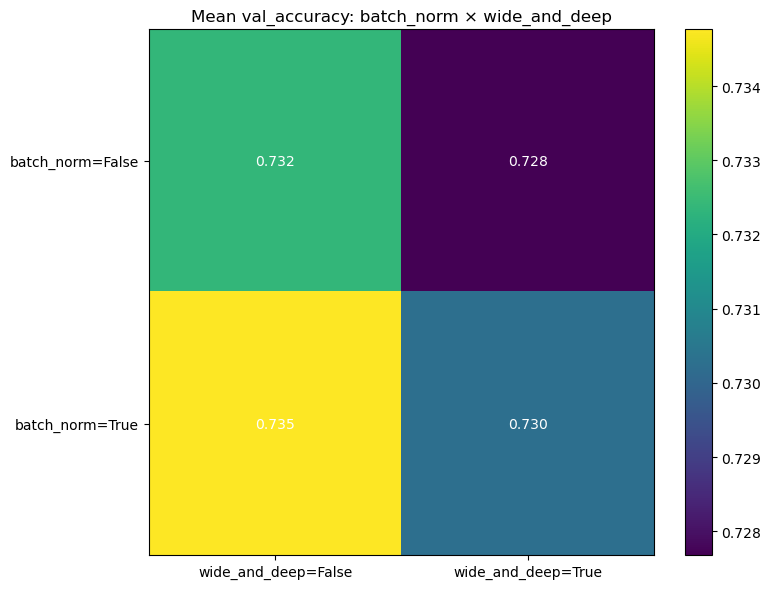

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))
pivot = df.pivot_table(values="val_accuracy", index="batch_norm",
                      columns="wide_and_deep", aggfunc="mean")
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"wide_and_deep={c}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"batch_norm={i}" for i in pivot.index])
ax.set_title("Mean val_accuracy: batch_norm × wide_and_deep")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}",
                ha="center", va="center", color="white")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("batchnorm_widedeep_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

Models on average perform best when batch norm is true and wide and deep is false. Theory Time: Wide and deep is not helping input too much. especially when subsetting. Batch normalization or Selu is a substitution seems almost essential for the model though.

A worry though: selu could be advantaged because of normalized inputs and not because of actual improvement. To see lets build a relu 

In [39]:
def build_test_relu(meta, mean, variance, seed=42):
    X_shape = meta["X_shape_"]
    n_features = X_shape[1]

    activation = "relu"
    n_hidden = 5
    #learning_rate = hp.Choice("learning_rate", values=[3e-4, 1e-3])
    #optimizer = hp.Choice("optimizer", values=["sgd", "adam"]) #Just adam for now
    batch_norm = True
    #decay_rate = hp.Float("decay_rate", min_value=0.9, max_value=0.99, step=0.01)
    wide_and_deep = False
    '''
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=learning_rate,
                decay_steps=100,
                decay_rate=decay_rate,
            )
        )
    '''
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=3e-3,
        decay_steps=687 * 50,
        warmup_target=3e-3,
        warmup_steps=687 * 2,  # 2 epochs of warmup
    )

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    inputs = tf.keras.layers.Input(shape=(n_features,))

    norm_layer = tf.keras.layers.Normalization(mean=mean, variance=variance)
    preprocessing = norm_layer(inputs)


    last_layer = preprocessing
    for i in range(n_hidden):
        n_neurons = 200
        last_layer = tf.keras.layers.Dense(n_neurons, activation=activation)(last_layer)
        if batch_norm:
            last_layer = tf.keras.layers.BatchNormalization()(last_layer)

    outputs = tf.keras.layers.Dense(4, activation="softmax")(last_layer)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

norm_layer = tf.keras.layers.Normalization()
norm_layer.adapt(x_tr_flat)
mean_, var_ = norm_layer.get_weights()[0], norm_layer.get_weights()[1]

model_relu = build_test_relu(meta=meta, mean=mean_, variance=var_)


In [40]:
results.append(train_eval_no_wrapper(
    model=model_relu,
    name="ReLu with best Hyperparams",
    x_tr=x_tr_flat,
    y_tr=y_tr,
    x_va=x_va_flat,
    y_va=y_va,
    sample_weights=sample_weights,
    callbacks=[early_stopping_cb]
))
               

Epoch 1/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4257 - loss: 1.3242
Epoch 2/50
 45/688 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4836 - loss: 1.2392

c:\Users\samue\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5141 - loss: 1.1584
Epoch 3/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5440 - loss: 1.0735
Epoch 4/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5774 - loss: 1.0193
Epoch 5/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5923 - loss: 0.9754
Epoch 6/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6006 - loss: 0.9474
Epoch 7/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6171 - loss: 0.9135
Epoch 8/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6187 - loss: 0.8821
Epoch 9/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6355 - loss: 0.8587
Epoch 10/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6428 - loss: 0.8373
Epoch 11/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6557 - loss: 0.8035
Epoch 12/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6676 - loss: 0.7833
Epoch 13/50
688/688 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accurac

Val Accuracy is siginificantly lower. for this model than our best from the search. This suggest that SELU could actually be viable.

In [88]:
model_names = [r["name"]   for r in results]
acc_scores  = [r["acc"]    for r in results]
prec_scores = [r["prec"]   for r in results]
rec_scores  = [r["recall"] for r in results]
f1_scores   = [r["f1"]     for r in results]

model_names

['Baseline ANN',
 'avg+median filtering results',
 'avg filtering results',
 'Wide & Deep baseline model',
 'Wide & Deep Average',
 'Wide & Deep Median + Avg model',
 'Wide & Deep with feature subsampling',
 'Best Hyperband Result',
 'ReLu with best Hyperparams',
 'Simple CNN',
 'Best Random Search',
 'Median CNN']

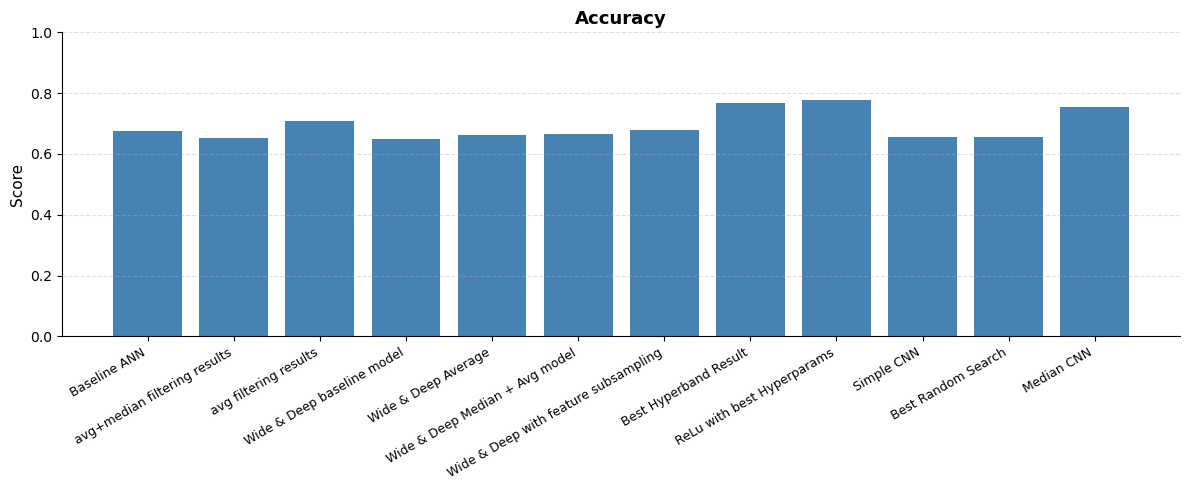

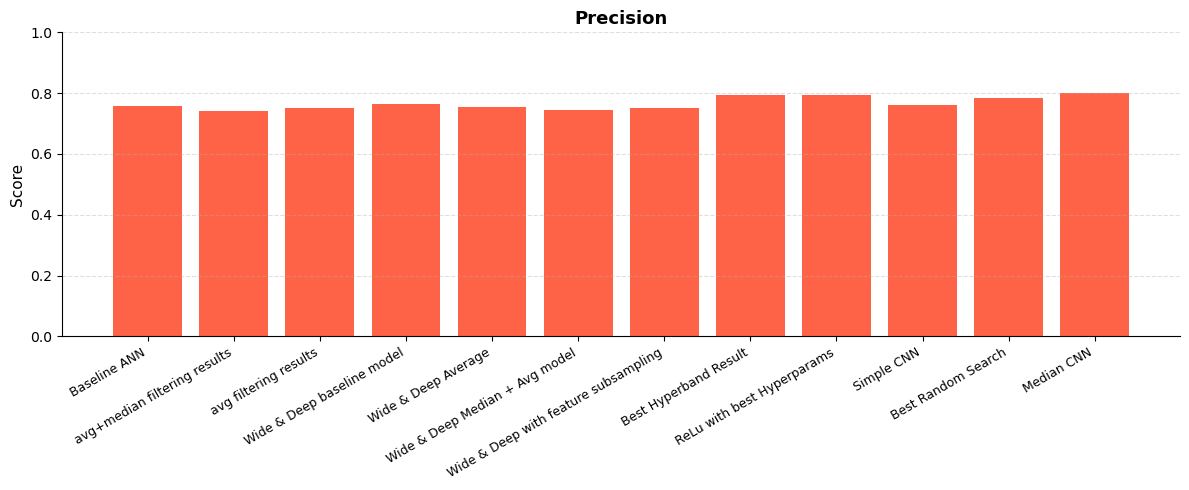

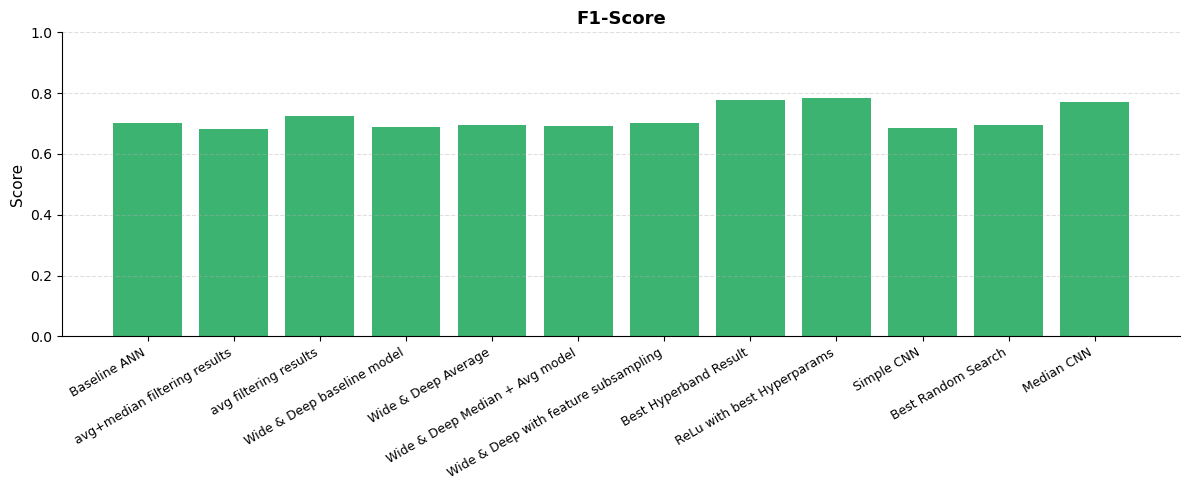

In [92]:
metrics = [
    ("Accuracy",  acc_scores,  'steelblue'),
    ("Precision", prec_scores, 'tomato'),
    ("F1-Score",  f1_scores,   'mediumseagreen'),
]

for metric_name, scores, color in metrics:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(np.arange(len(model_names)), scores, color=color)

    ax.set_title(metric_name, fontsize=13, fontweight='bold')
    ax.set_ylabel("Score", fontsize=11)
    ax.set_xticks(np.arange(len(model_names)))
    ax.set_xticklabels(model_names, rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'Figures/{metric_name}_All_Models')
    plt.show()